# Three-way mixed ANOVA changes in spm1d v0.4.54

(2026-09-17)

A bug was found in `spm1d.stats.anova3onerm` affecting all **spm1d** versions prior to v0.4.54.

The bug is **minor** in the sense that:
- It affects just one function: `anova3onerm`
- It is only expected to affect relatively rare use cases, and
- It is expected to have a relatively small effect on numerical results in most use cases

However the bug is **major** in the sense that:
- It affects numerical results, and could alter conclusions regarding factors relating to "C" (the repeated measures factor)
- All users who have used `anova3onerm` should re-run analysis with **spm1d** v0.4.54 or later

All users are therefore advised to upgrade **spm1d** to avoid this bug.


## Bug description

The defect affects the following procedures:

- `spm1d.stats.anova3onerm`
- `spm1d.stats.nonparam.anova3onerm`

In `anova3onerm` (i.e., three-way ANOVA with one repeated-measures factor) the error term for the main effect of C (and for all interactions involving C) was calculated incorrectly in some cases, because it incorrectly considered the number of levels of the B and C factors.

If `nB` and `nC` are the numbers of levels of the B and C factors, then the behaviour prior to v0.4.54 was:

| Case | Description |
|---|---|
| `nB` = `nC` | Correct |
| `nB` < `nC` | Error degrees of freedom and F-value incorrect for C, AxC, BxC and AxBxC terms |
| `nB` > `nC` | `ValueError` raised; no result returned |


**Note**: this bug does not affect cases where `nB` and `nC` are equal, and both
datasets distributed with previous versions of **spm1d** were of that kind, which
is why this bug remained undetected until recently.

`spm1d.stats.anova3tworm` and `spm1d.stats.anova3rm` are **not** affected.

Below is a description of the bug and a demonstration of its resolution in spm1d v0.4.54.

<br>
<br>

___

## Preliminaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import spm1d

Before starting verify that you have **spm1d** version 0.4.54 or later:

In [2]:
print( spm1d.__version__ )

0.4.54


Next let's define a context manager so that previous results can be shown alongside new results.

In [3]:
import contextlib
from spm1d.stats.anova.factors import FactorNestedTwoWay

def _get_design_interaction_pre0454(self, other): # this is code from pre-0.4.54 versions
    A,B,C,S  = self.NEST0.A, self.NEST1.A, other.A, self.A
    X        = []
    for uA in self.NEST0.u:
        for uB in self.NEST1.u[1:]:          # <-- dropped a level of B
            for uC in other.u:               # <-- kept every level of C
                uS = np.unique( S[(A==uA)&(B==uB)&(C==uC)] )
                for uuS in uS[1:]:
                    x = np.zeros(self.J)
                    x[(A==uA)&(B==uB)&(C==uC)&(S==uuS)] = 1
                    X.append(x)
    return np.asarray(X).T

@contextlib.contextmanager
def previous_version():
    original = FactorNestedTwoWay.get_design_interaction
    FactorNestedTwoWay.get_design_interaction = _get_design_interaction_pre0454
    try:
        yield
    finally:
        FactorNestedTwoWay.get_design_interaction = original

<br>
<br>

___

## Example of old and new behavior

The new [UCLA Exercise dataset](https://stats.oarc.ucla.edu/r/seminars/repeated-measures-analysis-with-r/) demonstrates the problem. This dataset has `nB` = 2 and `nC` = 3.

In [4]:
dataset   = spm1d.data.uv0d.anova3onerm.UCLAExercise()
y,A,B,C,S = dataset.get_data()

print( dataset )

Dataset
   Name      : "UCLAExercise"
   Design    :  Three-way ANOVA (repeated measures on one factor)
   Data dim  :  0
   testname  :  anova3onerm
   Web       :  https://stats.oarc.ucla.edu/r/seminars/repeated-measures-analysis-with-r/
  (Expected results)
  F          :  (47.9152, 14.5238, 31.7206, 4.6945, 20.9005, 2.9597, 4.7095)
  df         :  ((2, 24), (1, 24), (2, 48), (2, 24), (4, 48), (2, 48), (4, 48))
  p          :  (4.166e-09, 0.0008483, 1.662e-09, 0.019023, 4.992e-10, 0.06137, 0.00275)



Running analysis with the new version of **spm1d** yields the expected results:

In [5]:
LABELS = ['A', 'B', 'C', 'AB', 'AC', 'BC', 'ABC']

def compare(dataset, procedure, title='spm1d'):
    y,A,B,C,S = dataset.get_data()
    print('          %-27s%s' % ('expected results', title))
    try:
        spms = procedure(y, A, B, C, S, equal_var=True).inference(0.05)
    except Exception as e:
        print('          %s: %s' % (type(e).__name__, e))
        return
    for s,label,z,df in zip(spms, LABELS, dataset.z, dataset.df):
        agree = (abs(s.z - z) < dataset._atol) and (tuple(s.df) == tuple(df))
        print('    %-4s  F = %8.3f (%2g,%4g)     F = %8.3f (%2g,%4g)   %s'
              % (label, z, df[0], df[1], s.z, s.df[0], s.df[1], '' if agree else '<--'))

compare(dataset, spm1d.stats.anova3onerm, title='spm1d v0.4.54 and later')

          expected results           spm1d v0.4.54 and later
    A     F =   47.915 ( 2,  24)     F =   47.915 ( 2,  24)   
    B     F =   14.524 ( 1,  24)     F =   14.524 ( 1,  24)   
    C     F =   31.721 ( 2,  48)     F =   31.721 ( 2,  48)   
    AB    F =    4.694 ( 2,  24)     F =    4.695 ( 2,  24)   
    AC    F =   20.901 ( 4,  48)     F =   20.900 ( 4,  48)   
    BC    F =    2.960 ( 2,  48)     F =    2.960 ( 2,  48)   
    ABC   F =    4.710 ( 4,  48)     F =    4.709 ( 4,  48)   


Running with previous **spm1d** versions yields incorrect df and F values for C-related effects:

In [6]:
with previous_version():
    compare(dataset, spm1d.stats.anova3onerm, title='previous spm1d versions')

          expected results           previous spm1d versions
    A     F =   47.915 ( 2,  24)     F =   47.915 ( 2,  24)   
    B     F =   14.524 ( 1,  24)     F =   14.524 ( 1,  24)   
    C     F =   31.721 ( 2,  48)     F =   34.126 ( 2,  36)   <--
    AB    F =    4.694 ( 2,  24)     F =    4.695 ( 2,  24)   
    AC    F =   20.901 ( 4,  48)     F =   22.485 ( 4,  36)   <--
    BC    F =    2.960 ( 2,  48)     F =    3.184 ( 2,  36)   <--
    ABC   F =    4.710 ( 4,  48)     F =    5.067 ( 4,  36)   <--


<br>
<br>

___

## Order of factors A and B

For `anova3onerm`, both A and B are between-subject factors, so their order should not change results. However, in previous **spm1d** versions the A and B order mattered:

In [7]:
with previous_version():
    for tag, a, b in [('A, B', A, B), ('B, A', B, A)]:
        spms = spm1d.stats.anova3onerm(y, a, b, C, S, equal_var=True).inference(0.05)
        print('anova3onerm(y, %s C, SUBJ)     main effect of C:  F = %.4f  on (%g, %g)'
              % (tag + ',', spms[2].z, spms[2].df[0], spms[2].df[1]))

anova3onerm(y, A, B, C, SUBJ)     main effect of C:  F = 34.1257  on (2, 36)
anova3onerm(y, B, A, C, SUBJ)     main effect of C:  F = 31.7206  on (2, 48)


In v0.4.54 both orderings give the published result:

In [8]:
for tag, a, b in [('A, B', A, B), ('B, A', B, A)]:
    spms = spm1d.stats.anova3onerm(y, a, b, C, S, equal_var=True).inference(0.05)
    print('anova3onerm(y, %s C, SUBJ)     main effect of C:  F = %.4f  on (%g, %g)'
          % (tag + ',', spms[2].z, spms[2].df[0], spms[2].df[1]))

anova3onerm(y, A, B, C, SUBJ)     main effect of C:  F = 31.7206  on (2, 48)
anova3onerm(y, B, A, C, SUBJ)     main effect of C:  F = 31.7206  on (2, 48)


<br>
<br>

___

## Effect on p values

Since the bug affects both the F-value and degrees of freedom for C-related factors, the p-values are also affected. The new `RS3onerm` dataset demonstrates a representative range of expected p-value changes. Note that p-value change can alter "significance" conclusions at alpha=0.05 in some cases.

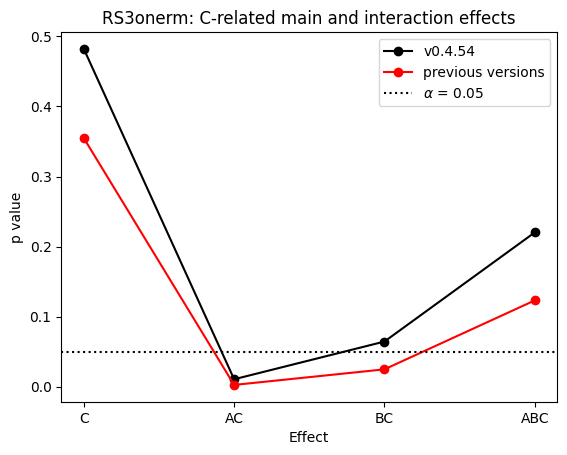

In [9]:
dataset2 = spm1d.data.uv0d.anova3onerm.RS3onerm()
y2,A2,B2,C2,S2 = dataset2.get_data()

new = spm1d.stats.anova3onerm(y2, A2, B2, C2, S2, equal_var=True).inference(0.05)
with previous_version():
    old = spm1d.stats.anova3onerm(y2, A2, B2, C2, S2, equal_var=True).inference(0.05)


ind = [2, 4, 5, 6]     # C-related factor indices

plt.figure()
ax = plt.axes()
ax.plot(range(4), [new[i].p for i in ind], 'ko-', label='v0.4.54')
ax.plot(range(4), [old[i].p for i in ind], 'ro-', label='previous versions')
ax.axhline(0.05, color='k', linestyle=':', label=r'$\alpha$ = 0.05')
ax.set_xticks( range(4) )
ax.set_xticklabels( [LABELS[i] for i in ind] )
ax.set_xlabel('Effect')
ax.set_ylabel('p value')
ax.set_title('RS3onerm: C-related main and interaction effects')
ax.legend()
plt.show()

<br>
<br>

___

## Designs with nB > nC

When nB > nC, previous **spm1d** versions raised a `ValueError`:

In [10]:
dataset3 = spm1d.data.uv0d.anova3onerm.DatariumPerformance()

with previous_version():
    compare(dataset3, spm1d.stats.anova3onerm, title='')

          expected results           
          ValueError: shapes (10,138) and (120,) not aligned: 138 (dim 1) != 120 (dim 0)


This error has been corrected in **spm1d** 0.4.54

In [11]:
compare(dataset3, spm1d.stats.anova3onerm)

          expected results           spm1d
    A     F =    2.406 ( 1,  54)     F =    2.406 ( 1,  54)   
    B     F =   21.166 ( 2,  54)     F =   21.166 ( 2,  54)   
    C     F =    0.063 ( 1,  54)     F =    0.063 ( 1,  54)   
    AB    F =    1.554 ( 2,  54)     F =    1.554 ( 2,  54)   
    AC    F =    4.730 ( 1,  54)     F =    4.730 ( 1,  54)   
    BC    F =    1.821 ( 2,  54)     F =    1.821 ( 2,  54)   
    ABC   F =    6.101 ( 2,  54)     F =    6.101 ( 2,  54)   


<br>
<br>

___

## 1D data

The same change applies to 1D data. `SPM1D_ANOVA3ONERM_2x3x4` is one of the two
1D datasets distributed with **spm1d** for this procedure, and it is a 2x3x4
design, so it is affected: the error degrees of freedom for the effects
involving C go from 64 to 72, which moves the critical threshold.

Main effect of C
   df (v0.4.54):           (3, 72)
   df (previous versions): (3, 64)
   zstar (v0.4.54):           4.56132
   zstar (previous versions): 4.61253


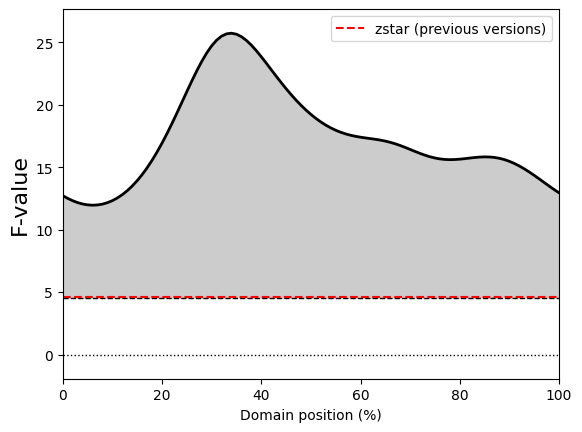

In [12]:
import warnings

dataset4  = spm1d.data.uv1d.anova3onerm.SPM1D_ANOVA3ONERM_2x3x4()
Y,A4,B4,C4,S4 = dataset4.get_data()

with warnings.catch_warnings(record=True) as w:
    f     = spm1d.stats.anova3onerm(Y, A4, B4, C4, S4, equal_var=True)[2].inference(0.05)
    with previous_version():
        f_old = spm1d.stats.anova3onerm(Y, A4, B4, C4, S4, equal_var=True)[2].inference(0.05)

print( 'Main effect of C' )
print( f'   df (v0.4.54):           {tuple(int(v) for v in f.df)}' )
print( f'   df (previous versions): {tuple(int(v) for v in f_old.df)}' )
print( f'   zstar (v0.4.54):           {f.zstar:.5f}' )
print( f'   zstar (previous versions): {f_old.zstar:.5f}' )

plt.figure()
ax = plt.axes()
f.plot(ax=ax)
ax.axhline(f_old.zstar, color='r', linestyle='--', label='zstar (previous versions)')
ax.set_xlabel('Domain position (%)')
ax.set_ylabel('F-value')
ax.legend()
plt.show()

<br>
<br>

___

## Unaffected scenarios

Designs in which the second and third factors have the same number of levels
are unaffected. `NYUCaffeine` is a 4x3x3 design, so the old and new results are
identical:

In [13]:
dataset5 = spm1d.data.uv0d.anova3onerm.NYUCaffeine()
compare(dataset5, spm1d.stats.anova3onerm, title='v0.4.54')
print()
with previous_version():
    compare(dataset5, spm1d.stats.anova3onerm, title='previous versions')

          expected results           v0.4.54
    A     F =   23.800 ( 3,  48)     F =   23.738 ( 3,  48)   
    B     F =   11.600 ( 2,  48)     F =   11.623 ( 2,  48)   
    C     F =  140.600 ( 2,  96)     F =  140.550 ( 2,  96)   
    AB    F =    1.650 ( 6,  48)     F =    1.653 ( 6,  48)   
    AC    F =    6.390 ( 6,  96)     F =    6.391 ( 6,  96)   
    BC    F =    5.450 ( 4,  96)     F =    5.451 ( 4,  96)   
    ABC   F =    2.250 (12,  96)     F =    2.252 (12,  96)   

          expected results           previous versions
    A     F =   23.800 ( 3,  48)     F =   23.738 ( 3,  48)   
    B     F =   11.600 ( 2,  48)     F =   11.623 ( 2,  48)   
    C     F =  140.600 ( 2,  96)     F =  140.550 ( 2,  96)   
    AB    F =    1.650 ( 6,  48)     F =    1.653 ( 6,  48)   
    AC    F =    6.390 ( 6,  96)     F =    6.391 ( 6,  96)   
    BC    F =    5.450 ( 4,  96)     F =    5.451 ( 4,  96)   
    ABC   F =    2.250 (12,  96)     F =    2.252 (12,  96)   


`spm1d.stats.anova3tworm` is unaffected for all designs; it uses a different subject factor.

`RS3tworm` is a 3x4x2 design, in which the two repeated-measures factors have different numbers of levels:

In [14]:
compare( spm1d.data.uv0d.anova3tworm.RS3tworm(), spm1d.stats.anova3tworm )

          expected results           spm1d
    A     F =    1.994 ( 2,  18)     F =    1.994 ( 2,  18)   
    B     F =    9.169 ( 3,  54)     F =    9.169 ( 3,  54)   
    C     F =   98.243 ( 1,  18)     F =   98.243 ( 1,  18)   
    AB    F =    3.211 ( 6,  54)     F =    3.211 ( 6,  54)   
    AC    F =   17.826 ( 2,  18)     F =   17.826 ( 2,  18)   
    BC    F =    6.067 ( 3,  54)     F =    6.067 ( 3,  54)   
    ABC   F =    4.179 ( 6,  54)     F =    4.179 ( 6,  54)   


<br>
<br>

___

## Summary

spm1d versions prior to v0.4.54 are subject to the `anova3onerm` bug described above.

- If `nC` == `nB`, your results are unaffected.
- If `nC` > `nB`, the error degrees of freedom and the *F* values for C-related effects were incorrect, and should be recomputed with v0.4.54 or later.
- If `nC` < `nB`, the procedure previously raised `ValueError` and produced no result; it now runs.
- `spm1d.stats.anova3tworm` and `spm1d.stats.anova3rm` are unaffected.

Four new 0D example datasets with unequal factor level counts --- demonstrating both the previous problem and its correction --- are distributed with v0.4.54:

- `anova3onerm`: `UCLAExercise`, `RS3onerm` and `DatariumPerformance`
- `anova3tworm`: `RS3tworm`

If you discover any additional problems or bugs, please post them to the [spm1d forum](https://github.com/0todd0000/spm1d/issues).